In [ ]:
import cv2
import numpy as np
import urllib.request

url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
req = urllib.request.urlopen(url)
arr = np.asarray(bytearray(req.read()), dtype=np.uint8)
img = cv2.imdecode(arr, cv2.IMREAD_GRAYSCALE)

mean_val = np.mean(img)
_, binary_case1 = cv2.threshold(img, mean_val, 255, cv2.THRESH_BINARY)

user_thresh = int(input("Enter the threshold value (0-255): "))
_, binary_case2 = cv2.threshold(img, user_thresh, 255, cv2.THRESH_BINARY)

cv2.imshow("Original Grayscale Image", img)
cv2.imshow("Case 1: Mean Intensity Threshold", binary_case1)
cv2.imshow("Case 2: User Input Threshold", binary_case2)

cv2.waitKey(0)
cv2.destroyAllWindows()


Enter the threshold value (0-255):  230


import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt

def grayscale_to_binary(url):
    req = urllib.request.urlopen(url)
    arr = np.asarray(bytearray(req.read()), dtype=np.uint8)
    img = cv2.imdecode(arr, cv2.IMREAD_GRAYSCALE)
    
    mean_intensity = np.mean(img)
    _, binary_mean = cv2.threshold(img, mean_intensity, 255, cv2.THRESH_BINARY)
    
    user_thresh = float(input("Enter a custom threshold value (0-255): "))
    _, binary_user = cv2.threshold(img, user_thresh, 255, cv2.THRESH_BINARY)
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Grayscale')
    
    plt.subplot(1, 3, 2)
    plt.imshow(binary_mean, cmap='gray')
    plt.title('Case 1: Mean Threshold')
    
    plt.subplot(1, 3, 3)
    plt.imshow(binary_user, cmap='gray')
    plt.title('Case 2: User Threshold')
    
    plt.show()

image_url = 'https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg'
grayscale_to_binary(image_url)

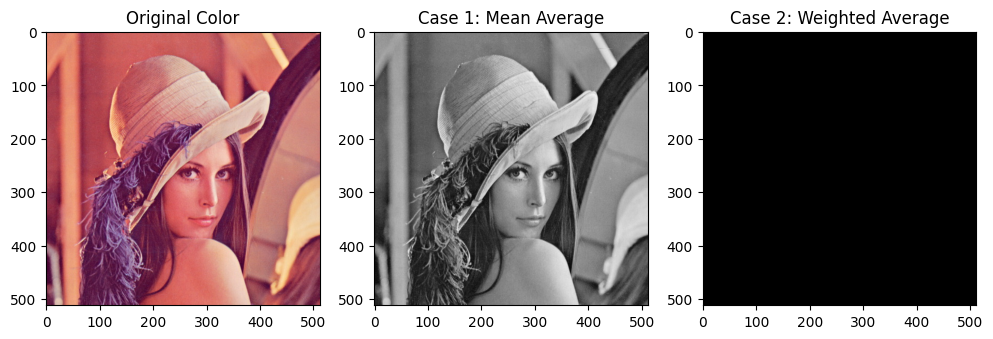

In [ ]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt

def rgb_to_grayscale(url):
    req = urllib.request.urlopen(url)
    arr = np.asarray(bytearray(req.read()), dtype=np.uint8)
    img_bgr = cv2.imdecode(arr, cv2.IMREAD_COLOR)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    b, g, r = cv2.split(img_bgr.astype(float))
    
    gray_mean = np.clip((r + g + b) / 3.0, 0, 255).astype(np.uint8)
    
    w_r = float(input("Weightage for R: "))
    w_g = float(input("Weightage for G: "))
    w_b = float(input("Weightage for B: "))
    
    gray_weighted = np.clip((w_r * r) + (w_g * g) + (w_b * b), 0, 255).astype(np.uint8)
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img_rgb)
    plt.title('Original Color')
    
    plt.subplot(1, 3, 2)
    plt.imshow(gray_mean, cmap='gray')
    plt.title('Case 1: Mean Average')
    
    plt.subplot(1, 3, 3)
    plt.imshow(gray_weighted, cmap='gray')
    plt.title('Case 2: Weighted Average')
    
    plt.show()

image_url = 'https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg'
rgb_to_grayscale(image_url)